In [1]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import os
import rasterio as rio
import pickle as pkl
import random

# modelling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
import joblib
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=UserWarning)

# Setup and Dataloading

In [37]:
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'
sites = os.listdir(data_dir)
test_sites = ['CG1-8B', 'F3-20B', 'CS-103A', 'ZF20-11A'] # Don't train on these
train_sites = [s for s in sites if s not in test_sites]
random.shuffle(train_sites)
non_predictive_columns = ['x_pos', 'y_pos', 'site', 'class_certainty', 'veg_class']

In [3]:
# Original data
df = pd.read_csv('dataset_file_transformed.csv')
df_reduced = df[df['class_certainty'] <= 2]

# Data with targetted labels added. Has extreme class imbalance
df_targetted = pd.read_csv('dataset_targetted_transformed.csv')
df_targetted_reduced = df_targetted[df_targetted['class_certainty'] <= 2]

# Hyperparameter Search
We use a custom CV and random search so that we can split the train and validation data by site

In [42]:
### Helper functions

# Simple dataframe splitting
def split_xy(df):
    feature_columns = [c for c in list(df.columns) if c not in non_predictive_columns]
    X = df[feature_columns]
    y = df['veg_class']
    return X, y


# More involved splitting, used when prototyping experiments
def split_by_sites(df, sites, split_xy=True):
    site_indices = df['site'].isin(sites)

    feature_columns = [c for c in list(df.columns) if c not in non_predictive_columns]
    X = df[feature_columns]
    y = df['veg_class']
    
    X_train = X[~site_indices].reset_index(drop=True)
    X_test = X[site_indices].reset_index(drop=True)
    y_train = y[~site_indices].reset_index(drop=True)
    y_test = y[site_indices].reset_index(drop=True)

    return X_train, X_test, y_train, y_test


In [46]:
# Run all CV splits and return results
def site_cross_validation(model, data, run_function, cut_size):
    '''
    `cuts` is a list of lists with site names used for cross validation
          ex: [ ['CS3A', 'ZF20-11A'], ['F3-20A', 'CG1-8A'], ... ]
    `sampling_function` is used to over / under sample to get around class imbalance
    '''
    train_accuracies = []
    val_accuracies = []
    
    data_sites = data['site'].unique()
    cv_cuts = [train_sites[i:i + cut_size] for i in range(0, len(train_sites), cut_size)]
    
    for cut in cv_cuts:
        train_data = data[~data['site'].isin(cut)]
        val_data = data[data['site'].isin(cut)]
        tr, va = run_function(model, train_data, val_data) # this is where experiment fn is called
        train_accuracies.append(tr)
        val_accuracies.append(va)
        
    return train_accuracies, val_accuracies

# Random search procedure
def random_search(data, model_class, param_dist, run_function, n_iterations=50, cut_size=4, n_jobs=8):
    '''
    data - dataframe containing all the data we want to train on
    model_class - the model class we're using for this experiment
    param_dist - dictionary with search space for random search
    run_function - custom function implementing experiment logic must have function signature:
            run_function(model, train_data, val_data) -> train_accuracy, val_accuracy:
    '''
    
    best_params = None
    best_accuracy = 0.0
    
    for i in range(n_iterations):
        params = {key: random.choice(value) for key, value in param_dist.items()}
        model = model_class(n_jobs=n_jobs, **params)
        print(f'Trying {params}')
        train_accuracies, val_accuracies = site_cross_validation(model, data, run_function, cut_size)
        
        print(f'  Val accuracies: {val_accuracies}')
        print(f'  Train accuracy mean: {mean(train_accuracies)}, Val accuracy mean: {mean(val_accuracies)}')
        if mean(val_accuracies) > best_accuracy:
            best_accuracy = mean(val_accuracies)
            best_params = params
    
    print(f'\nBest params: {best_params}. Average test accuracy: {best_accuracy}')

# Experiments
Since the data has high spatial (and site-level) autocorrelation, we have a custom procedure for running experiments.
In the above section, we defined a site-level cross-validation routine, and nested that inside a custom hyperparameter search
that uses that CV. So for each experiment, we just need to implement the core training logic.

- define a function first
  - inputs:
    - model - initialized sklearn model
    - train_data - dataframe with all data for train sites
    - val_data - dataframe with all data for validation sites
  - outputs:
    - train accuracy
    - val accuracy
  - this function will be used within the CV loop, nested inside random search

- define the data you will use (+/- targetted labels for example)
- define model type and parameter distribution

This structure allows for maximum flexibility with how you define an experiment. When prototyping, it is easiest to not use the
CV functionality, and instead structure it like this:

```
def my_custom_training_function(model, train_data, val_data):
    ...
    ...
    return model.score(X_res, y_res), model.score(X_train, y_train)

model = RandomForestClassifier({params})

my_custom_training_function(model, df[df['site'].isin(train_sites)], df[df['site'].isin(test_sites)])

```

Once the training function is working as expected, try plugging it into the random search routine.

In [47]:
def over_sample_no_targetted(model, train_data, val_data):
    X_train, y_train = split_xy(train_data)
    X_val, y_val = split_xy(val_data)
    
    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    over = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = over.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    model.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    return model.score(X_res, y_res), model.score(X_val, y_val)


data = df_reduced

model_type = RandomForestClassifier    

param_dist = { # discrete search space for random search
    'n_estimators': [400, 500, 600],
    'max_depth': [6, 8, 10, 12, 14],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}

experiment_fn = over_sample_no_targetted

# Run hyperparameter search with CV
random_search(data, model_type, param_dist, over_sample_no_targetted, n_iterations=5)

Trying {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1}
  Val accuracies: [0.6481427317929219, 0.5605330309044514, 0.5271453590192644, 0.640295358649789, 0.6560803474484256]
  Train accuracy mean: 0.7748681108604498, Val accuracy mean: 0.6064393655629704
Trying {'n_estimators': 500, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1}
  Val accuracies: [0.649020181339573, 0.575276438899915, 0.5226419814861146, 0.6595464135021097, 0.6473941368078175]
  Train accuracy mean: 0.678175409606707, Val accuracy mean: 0.610775830407106
Trying {'n_estimators': 600, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 1}
  Val accuracies: [0.6513600467973092, 0.5701729515168699, 0.5344008006004504, 0.6545358649789029, 0.6636807817589576]
  Train accuracy mean: 0.7179706986300032, Val accuracy mean: 0.6148300891304981
Trying {'n_estimators': 400, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 2}
  Val accuracies: [0.655162328166130

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

def random_under_sample_targetted(model, train_data, val_data):
    X_train, y_train = split_xy(train_data)
    X_val, y_val = split_xy(val_data)
    
    under = imblearn.under_sampling.RandomUnderSampler(sampling_strategy='majority') # resamples all classes but majority
    X_res, y_res = over.fit_resample(X_train, y_train)

    model.fit(X_res.values, y_res.values)

    return model.score(X_res, y_res), model.score(X_val, y_val)


data = df_targetted_reduced

model_type = RandomForestClassifier    

param_dist = { # discrete search space for random search
    'n_estimators': [400, 500, 600],
    'max_depth': [6, 8, 10, 12, 14],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}

experiment_fn = random_under_sample_targetted

# Run hyperparameter search with CV
random_search(data, model_type, param_dist, over_sample_no_targetted, n_iterations=5)

# Experimentation
Playing around with the data, and informal experiments

  Train accuracy: 0.6532483810319616
  Test accuracy: 0.703725606150207
                  0
chm        0.124340
bc         0.086007
rc+gc      0.076224
GLI        0.072565
gc         0.066371
MGRVI      0.064887
rc/gc      0.064051
rc         0.061329
Ikaw       0.059386
ExG        0.058332
ExB        0.055697
ExGmExR    0.039908
G          0.028196
B          0.023840
z_score_Y  0.023079
z_score_L  0.022706
Y          0.022139
L          0.019722
R          0.016589
ExR        0.014632


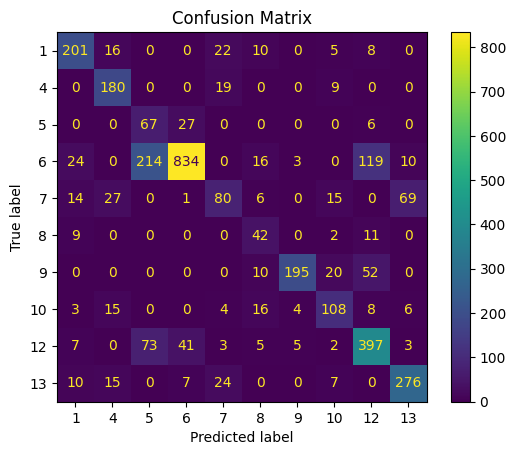

In [8]:
# Used for single experiments
def run_experiment(X_train, X_test, y_train, y_test, extra_metrics=False):
    # remove irrelevant columns
    X_train = X_train.drop(columns=non_predictive_columns)
    X_test = X_test.drop(columns=non_predictive_columns)

    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=600, max_depth=6, n_jobs=12)
    clf.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test.values)

    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

    if extra_metrics:
        # -----------------------------------------------------------------------------------------------------------
        # Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

        cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
        disp.plot()
        plt.title('Confusion Matrix')

        feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
        print(feature_importance)

    return clf, preds


X_train, X_test, y_train, y_test = split_by_sites(df_reduced, test_sites)
model, _ = run_experiment(X_train, X_test, y_train, y_test, extra_metrics=True)

In [118]:
df_majority = df[(df['veg_class'] == 1) & (df['class_certainty'] == 1)]
df_minority = df[(df['veg_class'] != 1) & (df['class_certainty'] <= 3)]

# Get count of minority class
minority_count = len(df_minority)

# Randomly sample from majority class to match the count of minority class
df_majority_downsampled = df_majority.sample(n=minority_count//3, random_state=42)

# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df_reduced = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)
df_reduced['veg_class'].value_counts()

veg_class
1     8381
6     7561
12    4984
10    2926
5     2293
9     1968
13    1570
8     1418
4     1235
7     1188
Name: count, dtype: int64

# Qualitative Evaluation
If you use these cells, make sure you ran the `2_process_validation_site.ipynb` notebook. Then use the code below to run inference on a whole site.

In [ ]:
site = 'CS-103A'
run_name = f'{site}_01'

# location of raw lichen data
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'

# place where we stored chunked feature data
run_dir = f'/network/scratch/m/matthew.fortier/runs/{run_name}'

In [14]:
site = 'CS-103A'
blocks = 4
chm = 3 # hard coded index of chm data

rgb_file = os.path.join(data_dir, site, f'{site}_hp_transparent_mosaic_group1.tif')

with rio.open(rgb_file) as f:
    meta = f.meta

curr_y = 0
curr_x = 0
h = 0
w = 0

output = np.zeros((meta['height'], meta['width']))
for y in range(blocks):
    for x in range(blocks):
        print(f'Processing block {y}-{x}')
        
        file_path = os.path.join(run_dir, 'composite', f'chunk_{y}_{x}.pkl')
        if not os.path.isfile(file_path):
            continue
    
        with open(file_path, "rb") as file:
            # Use pickle.load() to read the dictionary from the file
            block = pkl.load(file)
        h = block.shape[1]
        w = block.shape[2]
        
        block_output = np.zeros((h, w))
        
        # get coordinates of relevant pixels
        py, px = np.where(block[chm] >= 0)
        if len(py) > 0:
            features = block[:, py, px].T
            block_output[py, px] = model.predict(features)
            output[curr_y:curr_y+h, curr_x:curr_x+w] = block_output
            del features
        
        curr_x += w
        del block, block_output, py, px

    curr_x = 0
    curr_y += h
    

Processing block 0-0
Processing block 0-1
Processing block 0-2
Processing block 0-3
Processing block 1-0
Processing block 1-1
Processing block 1-2
Processing block 1-3
Processing block 2-0
Processing block 2-1
Processing block 2-2
Processing block 2-3
Processing block 3-0
Processing block 3-1
Processing block 3-2
Processing block 3-3


In [16]:
out_file = '/network/scratch/m/matthew.fortier/CS-103A-classified.tif'

meta.update(count=1)

# Write a new .tif file using the metadata from the original file
with rio.open(out_file, 'w', **meta) as dst:
    dst.write(output, 1)

# Misc code
Old code that I'm keeping around in case I need to refer back to it.

In [ ]:
conf_matrix = confusion_matrix(y_targ, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()

In [ ]:
pd.DataFrame(y_pred).value_counts()

In [ ]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname = f'perm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [ ]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 